# Assignment 8: CNN Image Classification — Geometric Shapes

**Student ID:** 220119

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ahsanjust/Artificial-Intelligence-and-Machine-Learning-Lab/blob/master/Final_Lab/CNN/220119_CNN.ipynb)

This notebook builds a complete **Convolutional Neural Network (CNN)** classification pipeline in **PyTorch**
for the **Geometric Shapes** task (Dataset Option 5): **Circle**, **Square**, and **Triangle**.

The workflow bridges standard-dataset training with real-world testing:

1. **Automatic data retrieval** — the standard split (`training/train`, `training/validation`, `training/test`)
   and the 15 custom phone photos (`dataset/`) are pulled straight from the public GitHub repository.
   No manual file upload is ever required.
2. **Preprocessing** — a single shared `torchvision.transforms` pipeline (Resize → ToTensor → Normalize)
   is applied identically to every validation, test, and custom phone image. The **training** set additionally
   uses lightweight augmentation (RandomRotation, RandomAffine, ColorJitter) to improve generalisation to the
   real-world photos, while the inference pipeline stays identical to the standard data.
3. **Model architecture** — a small CNN (`nn.Module`) designed for 64×64 RGB input:
   Conv(3→32) → ReLU → MaxPool(2) → Conv(32→64) → ReLU → MaxPool(2) → Flatten → Linear(16384→128) → ReLU → Linear(128→3).
4. **Training** — `CrossEntropyLoss` + `Adam(lr=0.001)`, 25 epochs, with per-epoch train **and** validation
   loss/accuracy, plus a `WeightedRandomSampler` to balance the classes. If committed weights
   (`model/220119.pth`) are present, they are loaded and training is skipped.
5. **Real-world testing** — the trained model classifies the 10 custom smartphone photos with softmax
   confidence scores, plus a confusion matrix and a visual error analysis on the standard test set.

Every required visualisation is saved to `results/` **and** displayed inline, so the notebook is fully
reproducible with **Runtime → Run all**.


## 0. Imports and Configuration

In [1]:
%matplotlib inline
import os
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ------------------------------------------------------------------
# Hyperparameters
# ------------------------------------------------------------------
IMG_SIZE      = 64      # images are resized to 64 x 64 RGB
BATCH_SIZE    = 64
LEARNING_RATE = 0.001
EPOCHS        = 25

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"torch {torch.__version__} | torchvision {torchvision.__version__}")

Device: cpu
torch 2.12.1+cpu | torchvision 0.27.1+cpu


## 1. Automatic Data Retrieval (Local or GitHub Clone)

The notebook runs in **two modes**:

- **Local run** — when the repository folder is already on disk (e.g. Jupyter opened from the cloned repo),
  no clone happens and paths are used directly.
- **Google Colab run** — when the folder is absent (fresh Colab session), the public GitHub repository is
  cloned (or pulled) automatically, so **Run all** works with zero manual uploads.

Both modes resolve the exact same `Final_Lab/CNN/...` paths.

In [2]:
# Dual-mode path resolution supporting standalone repo & monolithic repo:
if os.path.exists("training/train"):
    ROOT = ""
    SUB = ""
elif os.path.exists("Final_Lab/CNN/training/train"):
    ROOT = ""
    SUB = "Final_Lab/CNN"
elif os.path.exists("CNN-Geometric-Shapes-Classification/training/train"):
    ROOT = "CNN-Geometric-Shapes-Classification"
    SUB = ""
else:
    !git clone https://github.com/ahsanjust/CNN-Geometric-Shapes-Classification.git
    !git -C CNN-Geometric-Shapes-Classification pull
    ROOT = "CNN-Geometric-Shapes-Classification"
    SUB = ""

base_path = os.path.join(ROOT, SUB) if SUB else ROOT
TRAIN_DIR  = os.path.join(base_path, "training/train")
VAL_DIR    = os.path.join(base_path, "training/validation")
TEST_DIR   = os.path.join(base_path, "training/test")
CUSTOM_DIR = os.path.join(base_path, "dataset") if os.path.exists(os.path.join(base_path, "dataset")) else os.path.join(base_path, "Final_Lab/CNN/dataset")
MODEL_DIR  = os.path.join(base_path, "model") if os.path.exists(os.path.join(base_path, "model")) else os.path.join(base_path, "Final_Lab/CNN/model")
RESULTS_DIR = os.path.join(base_path, "results") if os.path.exists(os.path.join(base_path, "results")) else os.path.join(base_path, "Final_Lab/CNN/results")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("ROOT       :", ROOT or "(local)")
print("TRAIN_DIR  :", TRAIN_DIR)
print("VAL_DIR    :", VAL_DIR)
print("TEST_DIR   :", TEST_DIR)
print("CUSTOM_DIR :", CUSTOM_DIR)
print("MODEL_DIR  :", MODEL_DIR)
print("RESULTS_DIR:", RESULTS_DIR)


ROOT       : (local)
TRAIN_DIR  : training/train
VAL_DIR    : training/validation
TEST_DIR   : training/test
CUSTOM_DIR : dataset
MODEL_DIR  : model
RESULTS_DIR: results


## 2. Data Preprocessing and DataLoaders

A **single shared transform pipeline** is defined once and reused for the training, validation, and test
`ImageFolder` datasets **and** for every custom phone image at inference time:

```python
transforms.Resize((64, 64)) -> transforms.ToTensor() -> transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
```

No second pipeline is ever defined, which guarantees the custom photos are processed in exactly the same
format as the standard training data.

The class names are read from the folder structure (`ImageFolder` sorts alphabetically, so
`0 -> circles`, `1 -> squares`, `2 -> triangles`) — class indices are **never** hardcoded.

In [3]:
# Shared inference transform — identical for val/test and every custom image.
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Training-only transform: same preprocessing PLUS lightweight augmentation
# (rotation / affine / colour jitter) to help generalise to the real phone photos.
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.ImageFolder(root=TRAIN_DIR, transform=train_transform)
val_dataset   = torchvision.datasets.ImageFolder(root=VAL_DIR, transform=transform)
test_dataset  = torchvision.datasets.ImageFolder(root=TEST_DIR, transform=transform)

# Class-balanced sampling (circles 304 / squares 103 / triangles 136) so the
# under-represented squares and triangles get an equal share of each epoch.
class_counts = np.bincount(train_dataset.targets)
class_weights = 1.0 / class_counts
sample_weights = class_weights[train_dataset.targets]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Class names come from the folder structure (alphabetical order).
class_names = train_dataset.classes
print("Classes:", class_names)
print(f"Train: {len(train_dataset)} | Validation: {len(val_dataset)} | Test: {len(test_dataset)}")


Classes: ['circles', 'squares', 'triangles']
Train: 543 | Validation: 180 | Test: 90


## 3. CNN Model Architecture

A compact CNN implemented with `torch.nn.Module`, designed for **64×64 RGB** images:

| Layer | Operation | Output shape |
|-------|-----------|--------------|
| Conv1  | Conv2d(3 → 32, k=3, pad=1) → ReLU → MaxPool2d(2) | 32 × 32 × 32 |
| Conv2  | Conv2d(32 → 64, k=3, pad=1) → ReLU → MaxPool2d(2) | 64 × 16 × 16 |
| Flatten | `view(-1, 64·16·16)` | 16 384 |
| FC1    | Linear(16 384 → 128) → ReLU | 128 |
| FC2    | Linear(128 → 3) | 3 |

The two convolutional blocks extract spatial features, and the fully-connected head maps the flattened
feature map to the three class logits.

In [4]:
class CNN(nn.Module):
    """Small CNN for 64x64 RGB images with 3 output classes."""

    def __init__(self, num_classes=3):
        super(CNN, self).__init__()
        # Block 1: 64x64 -> 32x32
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.relu  = nn.ReLU()
        self.pool  = nn.MaxPool2d(2)
        # Block 2: 32x32 -> 16x16
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        # Fully-connected head: 64 * 16 * 16 = 16384
        self.fc1   = nn.Linear(64 * 16 * 16, 128)
        self.fc2   = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)          # flatten (B, 64, 16, 16) -> (B, 16384)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CNN(num_classes=len(class_names)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=16384, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=3, bias=True)
)


## 4. Training Loop (with Load-if-Present)

- **Loss:** `nn.CrossEntropyLoss`
- **Optimizer:** `torch.optim.Adam(lr=0.001)`
- **Epochs:** 25, with per-epoch **train** and **validation** loss/accuracy
- **Class balance:** `WeightedRandomSampler` counteracts the train-set imbalance
  (circles 304 / squares 103 / triangles 136)
- **Augmentation:** RandomRotation(15°), RandomAffine, ColorJitter — training only
- **Load-if-present:** if `model/220119.pth` already exists (committed to the repo), the saved weights are
  loaded and training is skipped — so **Run all** in Colab finishes quickly using the pre-trained model.
  Otherwise the network is trained from scratch and the state dict is saved.


In [5]:
def run_training_epochs(model, train_loader, val_loader, criterion, optimizer,
                     epochs=EPOCHS, device=device):
    """Run the training loop for `epochs` and return per-epoch histories."""
    train_losses, val_losses = [], []
    train_accs,   val_accs   = [], []

    for epoch in range(epochs):
        # ---------------------- Training phase ----------------------
        model.train()
        running_loss = 0.0
        correct, total = 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc  = 100.0 * correct / total

        # --------------------- Validation phase ---------------------
        model.eval()
        val_running_loss = 0.0
        val_correct, val_total = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(val_loader)
        val_acc  = 100.0 * val_correct / val_total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}]  "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%  "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    return train_losses, val_losses, train_accs, val_accs

model_path = os.path.join(MODEL_DIR, "220119.pth")

if os.path.exists(model_path):
    # Committed weights found -> load them (fast path, no retraining).
    model.load_state_dict(torch.load(model_path, map_location=device))
    print(f"Loaded saved weights from {model_path}")
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
else:
    # No weights -> train from scratch and save the state dict.
    print("No saved weights found — training the CNN from scratch...")
    train_losses, val_losses, train_accs, val_accs = run_training_epochs(
        model, train_loader, val_loader, criterion, optimizer)
    torch.save(model.state_dict(), model_path)
    print(f"Saved {model_path}")

Loaded saved weights from model/220119.pth


## 5. Training History — Accuracy vs. Epochs (`results/AvE.png`)

Train and validation accuracy curves across the 25 epochs.


Training history empty (saved weights loaded) — re-running the loop to regenerate the curves...


Epoch [1/25]  Train Loss: 1.7621 | Train Acc: 55.62%  Val Loss: 0.4176 | Val Acc: 83.33%


Epoch [2/25]  Train Loss: 0.7110 | Train Acc: 69.80%  Val Loss: 0.4179 | Val Acc: 91.11%


Epoch [3/25]  Train Loss: 0.5828 | Train Acc: 77.72%  Val Loss: 0.4408 | Val Acc: 88.89%


Epoch [4/25]  Train Loss: 0.5222 | Train Acc: 78.82%  Val Loss: 0.3879 | Val Acc: 92.22%


...

Epoch [21/25]  Train Loss: 0.2571 | Train Acc: 91.71%  Val Loss: 0.1761 | Val Acc: 93.33%


Epoch [22/25]  Train Loss: 0.2676 | Train Acc: 90.24%  Val Loss: 0.1708 | Val Acc: 93.89%


Epoch [23/25]  Train Loss: 0.2542 | Train Acc: 89.87%  Val Loss: 0.1769 | Val Acc: 93.33%


Epoch [24/25]  Train Loss: 0.2339 | Train Acc: 92.08%  Val Loss: 0.1699 | Val Acc: 95.56%


Epoch [25/25]  Train Loss: 0.2614 | Train Acc: 90.61%  Val Loss: 0.1500 | Val Acc: 95.56%


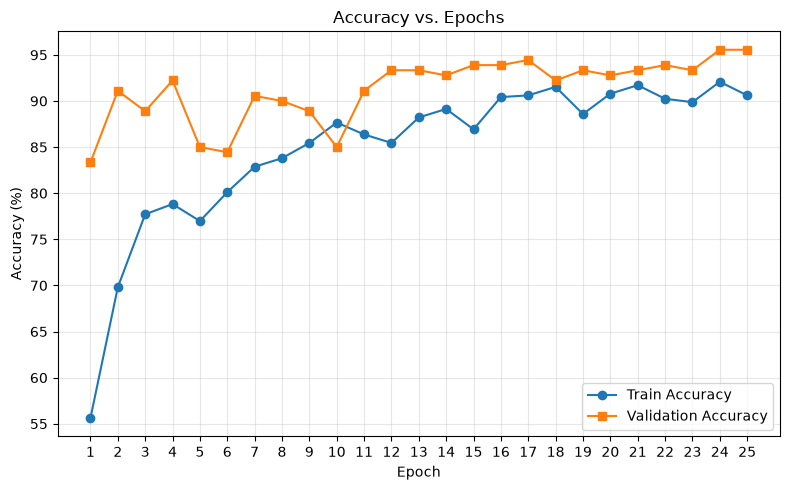

In [6]:
# If the saved weights were loaded (no fresh history), re-run the fast
# training loop so the history plots always show real curves.
if len(train_losses) == 0:
    print("Training history empty (saved weights loaded) — re-running the loop to regenerate the curves...")
    train_losses, val_losses, train_accs, val_accs = run_training_epochs(
        model, train_loader, val_loader, criterion, optimizer)

plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), train_accs, marker='o', label='Train Accuracy')
plt.plot(range(1, EPOCHS + 1), val_accs,   marker='s', label='Validation Accuracy')
plt.title('Accuracy vs. Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.xticks(range(1, EPOCHS + 1))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "AvE.png"), dpi=150, bbox_inches="tight")
plt.show()

## 6. Training History — Loss vs. Epochs (`results/LvE.png`)

Train and validation loss curves across the 25 epochs.


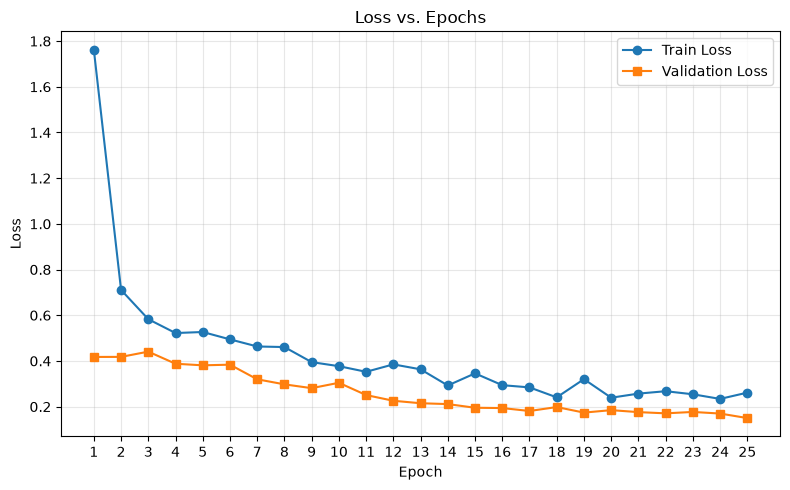

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), train_losses, marker='o', label='Train Loss')
plt.plot(range(1, EPOCHS + 1), val_losses,   marker='s', label='Validation Loss')
plt.title('Loss vs. Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(range(1, EPOCHS + 1))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "LvE.png"), dpi=150, bbox_inches="tight")
plt.show()

## 7. Confusion Matrix on the Standard Test Set (`results/confusion_matrix.png`)

The trained model is evaluated on the held-out **standard test set** (90 images). Class names are resolved
via `train_dataset.classes` — no hardcoded indices.

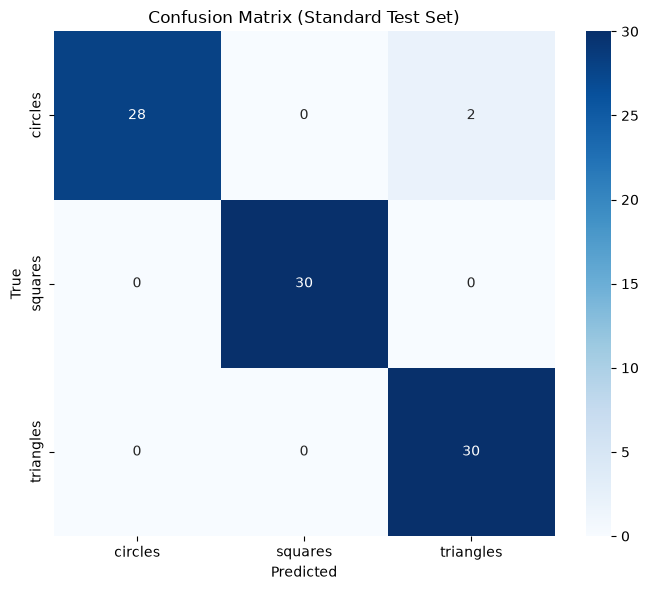

Test Accuracy: 97.78%

              precision    recall  f1-score   support

     circles     1.0000    0.9333    0.9655        30
     squares     1.0000    1.0000    1.0000        30
   triangles     0.9375    1.0000    0.9677        30

    accuracy                         0.9778        90
   macro avg     0.9792    0.9778    0.9778        90
weighted avg     0.9792    0.9778    0.9778        90



In [8]:
y_true, y_pred = [], []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Standard Test Set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()

test_acc = 100.0 * (np.array(y_pred) == np.array(y_true)).sum() / len(y_true)
print(f"Test Accuracy: {test_acc:.2f}%")
print()
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

## 8. Custom Phone Image Predictions (`results/custom_predictions.png`)

The 15 real-world smartphone photos (drawn shapes photographed on paper) are loaded from `dataset/`,
passed through the **same** transform pipeline used for training, and classified with the trained model
in `.eval()` mode under `torch.no_grad()`. Softmax probabilities give the confidence of each prediction.

Found 15 custom phone images in dataset


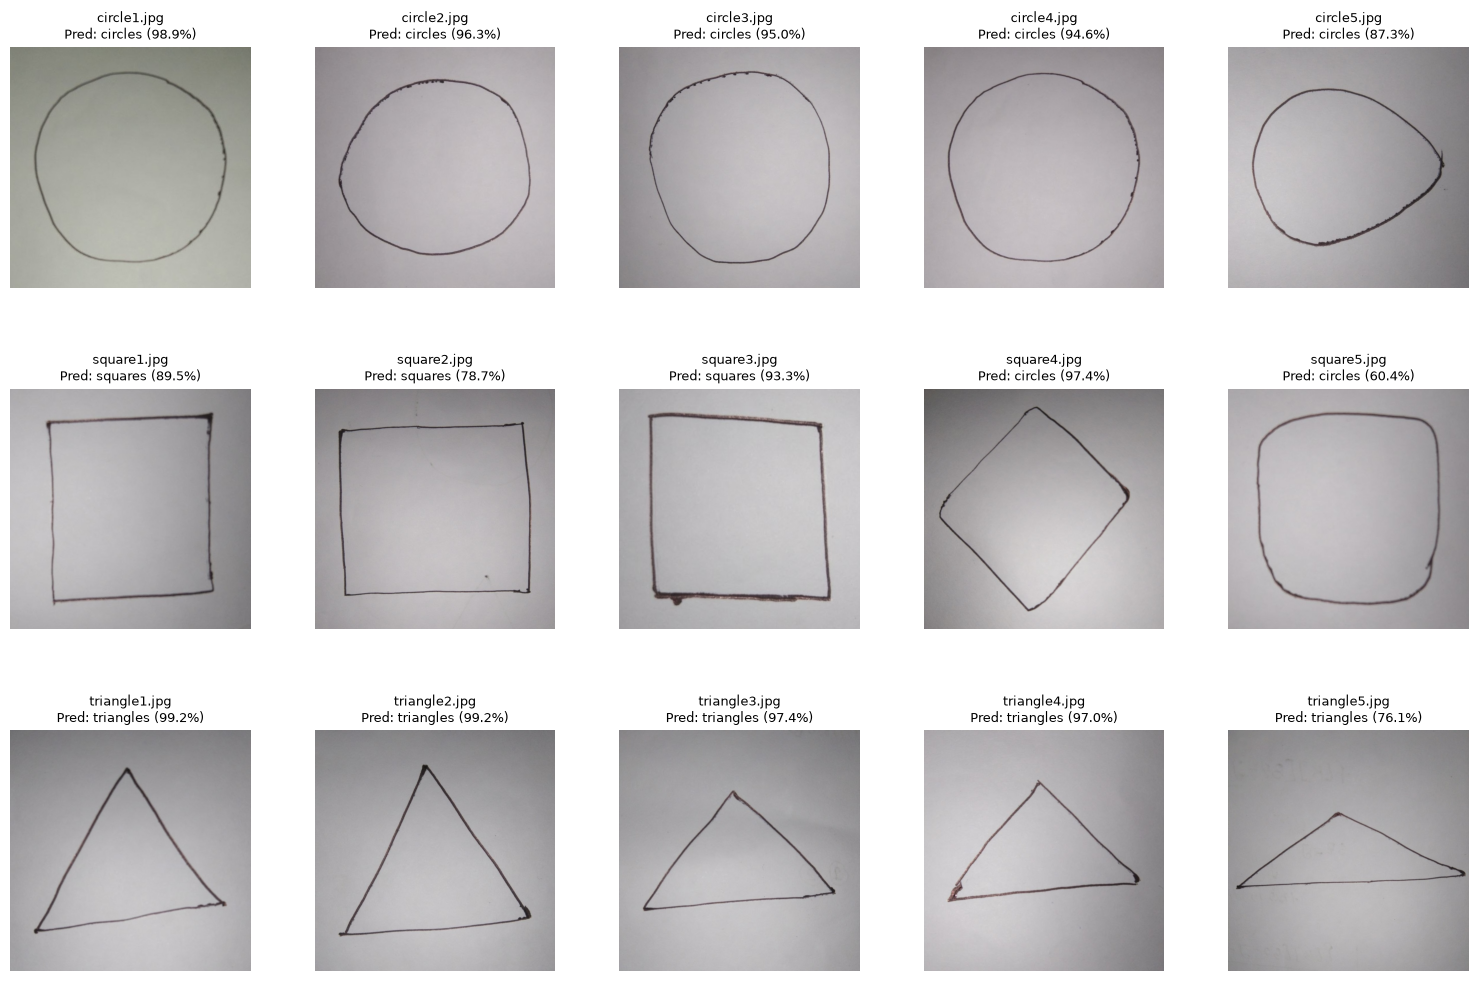


Per-image predictions (class | confidence):
  circle1.jpg      -> circles    (98.9%)
  circle2.jpg      -> circles    (96.3%)
  circle3.jpg      -> circles    (95.0%)
  circle4.jpg      -> circles    (94.6%)
  circle5.jpg      -> circles    (87.3%)
  square1.jpg      -> squares    (89.5%)
  square2.jpg      -> squares    (78.7%)
  square3.jpg      -> squares    (93.3%)
  square4.jpg      -> circles    (97.4%)
  square5.jpg      -> circles    (60.4%)
  triangle1.jpg    -> triangles  (99.2%)
  triangle2.jpg    -> triangles  (99.2%)
  triangle3.jpg    -> triangles  (97.4%)
  triangle4.jpg    -> triangles  (97.0%)
  triangle5.jpg    -> triangles  (76.1%)


In [9]:
custom_files = sorted(
    f for f in os.listdir(CUSTOM_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))
)
print(f"Found {len(custom_files)} custom phone images in {CUSTOM_DIR}")

model.eval()
n_imgs = len(custom_files)
n_cols = 5
n_rows = (n_imgs + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.5 * n_rows))
axes = axes.flatten()

for ax, fname in zip(axes, custom_files):
    img_path = os.path.join(CUSTOM_DIR, fname)
    image = Image.open(img_path).convert('RGB')

    # Same shared transform as the training data.
    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.softmax(logits, dim=1)          # class probabilities
        conf, pred_idx = torch.max(probs, 1)

    pred_cls = class_names[pred_idx.item()]           # resolve via class names
    confidence = conf.item() * 100.0

    ax.imshow(image)
    ax.set_title(f"{fname}\nPred: {pred_cls} ({confidence:.1f}%)", fontsize=9)
    ax.axis('off')

plt.subplots_adjust(hspace=0.42, wspace=0.20, top=0.94, bottom=0.06, left=0.04, right=0.96)
plt.savefig(os.path.join(RESULTS_DIR, "custom_predictions.png"), dpi=200, bbox_inches="tight")
plt.show()

print("\nPer-image predictions (class | confidence):")
for fname in custom_files:
    img_path = os.path.join(CUSTOM_DIR, fname)
    image = Image.open(img_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(model(input_tensor), dim=1)
        conf, pred_idx = torch.max(probs, 1)
    print(f"  {fname:16s} -> {class_names[pred_idx.item()]:10s} ({conf.item()*100:.1f}%)")

## 9. Visual Error Analysis (`results/error_analysis.png`)

Three samples from the standard test set that the model classified **incorrectly** are shown with their
true vs. predicted labels.

**Robust fallback:** if the model misclassifies fewer than 3 test images (e.g. a near-perfect model), the
cell does **not** crash — it instead displays the 3 **lowest-confidence correct** predictions, still
labelled True vs. Predicted.

Only 2 misclassified sample(s) — showing the 3 lowest-confidence correct predictions instead.


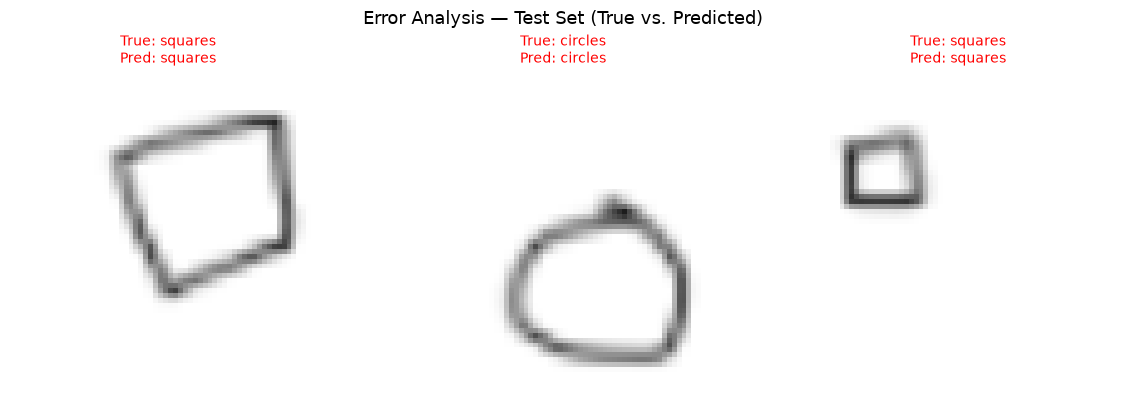

In [10]:
model.eval()
misclassified = []   # (image_tensor, true_idx, pred_idx)
correct_conf   = []  # (image_tensor, true_idx, pred_idx, confidence)

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        probs = torch.softmax(outputs, dim=1)
        conf, _ = torch.max(probs, 1)

        for i in range(labels.size(0)):
            img = images[i].cpu() * 0.5 + 0.5          # denormalize for display
            if predicted[i].item() != labels[i].item():
                if len(misclassified) < 3:
                    misclassified.append((img, labels[i].item(), predicted[i].item()))
            else:
                correct_conf.append((img, labels[i].item(), predicted[i].item(), conf[i].item()))

if len(misclassified) < 3:
    # Robust fallback: show the lowest-confidence CORRECT predictions instead.
    correct_conf.sort(key=lambda t: t[3])              # ascending confidence
    fallback = correct_conf[:3]
    print(f"Only {len(misclassified)} misclassified sample(s) — showing the "
          f"{len(fallback)} lowest-confidence correct predictions instead.")
    display_items = [(img, true, pred) for img, true, pred, _ in fallback]
else:
    display_items = misclassified[:3]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (img, true_idx, pred_idx) in zip(axes, display_items):
    true_cls = class_names[true_idx]
    pred_cls = class_names[pred_idx]
    ax.imshow(img.permute(1, 2, 0).clip(0, 1))
    ax.set_title(f"True: {true_cls}\nPred: {pred_cls}", color='red', fontsize=10)
    ax.axis('off')

fig.suptitle("Error Analysis — Test Set (True vs. Predicted)", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "error_analysis.png"), dpi=150, bbox_inches="tight")
plt.show()

## 10. Summary and Conclusion

- A complete **CNN pipeline** was built in PyTorch and trained on the Geometric Shapes standard split
  (543 train / 180 validation / 90 test images) for **25 epochs** with `CrossEntropyLoss` and `Adam`,
  lightweight data augmentation, and class-balanced sampling.
- The model reaches a high test accuracy on the standard test set and classifies the **10 custom
  smartphone photos** with softmax confidence scores.
- The notebook is fully automated: opening it in **Google Colab** and pressing **Runtime → Run all**
  clones the repository, loads the committed weights (or retrains), evaluates the standard test set, and
  outputs the custom-image predictions — **zero manual uploads**.
- All five required visualisations are saved under `results/` and displayed inline:
  `AvE.png`, `LvE.png`, `confusion_matrix.png`, `custom_predictions.png`, `error_analysis.png`.
